# B-41 Generación de sismograma sintético

Flujo final limpio en dominio TWT:

1. Carga y lectura del archivo.
2. Cálculo de logs adicionales.
3. Cálculo de ondícula Ricker.
4. Flujo único remuestreado: `AI -> AI filtrada -> RC -> SYNTHETIC`.
5. Un único plot final con tracks en TWT.

In [1]:
import pandas as pd

from functions.io_logs import parse_ascii_las_like
from functions.log_transforms import add_time_domain_logs, add_ai
from functions.resampling import filter_ai_and_resample
from functions.wavelet import ricker_wavelet, synthetic_from_rc
from functions.plotting import plot_final_twt_tracks

In [2]:
# Parametros
FILE_PATH = r"C:\Users\rfaro\Documents\Cursor\data\B-41_logs.txt"
NULL_VALUE = -999.25

# Flujo final confirmado
MEDIAN_WINDOW = 10
RESAMPLE_DT_MS = 2.0
RICKER_F0_HZ = 20.0
RICKER_LEN_MS = 128.0
RICKER_DT_MS = 2.0

In [3]:
# 1) Carga y lectura + logs adicionales
df_raw = parse_ascii_las_like(FILE_PATH, NULL_VALUE)
df_time = add_time_domain_logs(df_raw)
df_time = add_ai(df_time)

print(f"Filas leidas: {len(df_raw):,}")
df_time[["DEPT", "GR", "RHOB", "DT", "VEL_FROM_SONIC_MPS", "IA", "TWT_MS"]].head()

Filas leidas: 16,451


,DEPT,GR,RHOB,DT,VEL_FROM_SONIC_MPS,IA,TWT_MS
0,883.9200,21.8664,NaN,52.0500,5855.907781,NaN,0.052050
1,884.0724,22.8978,NaN,52.5606,5799.020559,NaN,0.104611
2,884.2248,22.9001,NaN,53.6378,5682.559687,NaN,0.158248
3,884.3772,21.2844,NaN,56.1973,5423.748116,NaN,0.214446
4,884.5296,20.4530,NaN,60.6788,5023.171190,NaN,0.275125


In [4]:
# 2) Ondicula Ricker
wavelet_t_ms, ricker = ricker_wavelet(
    f0_hz=RICKER_F0_HZ,
    length_ms=RICKER_LEN_MS,
    dt_ms=RICKER_DT_MS,
)

print(f"Ondicula Ricker: {len(ricker)} muestras")
pd.DataFrame({"t_ms": wavelet_t_ms, "ricker": ricker}).head()

Ondicula Ricker: 65 muestras


,t_ms,ricker
0,-64.0,-0.000003
1,-62.0,-0.000008
2,-60.0,-0.000018
3,-58.0,-0.000044
4,-56.0,-0.000100


In [5]:
# 3) Flujo unico remuestreado: AI filtrada -> RC remuestreado
final_df = filter_ai_and_resample(
    ai_df=df_time[["TWT_MS", "GR", "RHOB", "VEL_FROM_SONIC_MPS", "IA"]],
    dt_ms=RESAMPLE_DT_MS,
    median_window=MEDIAN_WINDOW,
)

# 4) Sintetico remuestreado desde RC
final_df["SYNTHETIC"] = synthetic_from_rc(final_df["RC"].to_numpy(), ricker)

print(f"Filas finales remuestreadas: {len(final_df):,}")
final_df[["TWT_MS_REG", "GR", "RHOB", "VEL_FROM_SONIC_MPS", "AI_FILTERED", "RC", "SYNTHETIC"]].head()

Filas finales remuestreadas: 749


,TWT_MS_REG,GR,RHOB,VEL_FROM_SONIC_MPS,AI_FILTERED,RC,SYNTHETIC
0,11.18344,21.834400,2.157600,5428.288006,11487.240543,-0.336265,-0.319516
1,13.18344,16.413697,2.056515,2435.337189,5705.821207,0.032171,-0.302149
2,15.18344,29.605189,2.126847,2849.530118,6085.145125,-0.023660,-0.256063
3,17.18344,38.058095,2.024761,2836.353244,5803.847793,0.009135,-0.186959
4,19.18344,29.715137,2.063768,2899.520051,5910.864601,0.042488,-0.103508


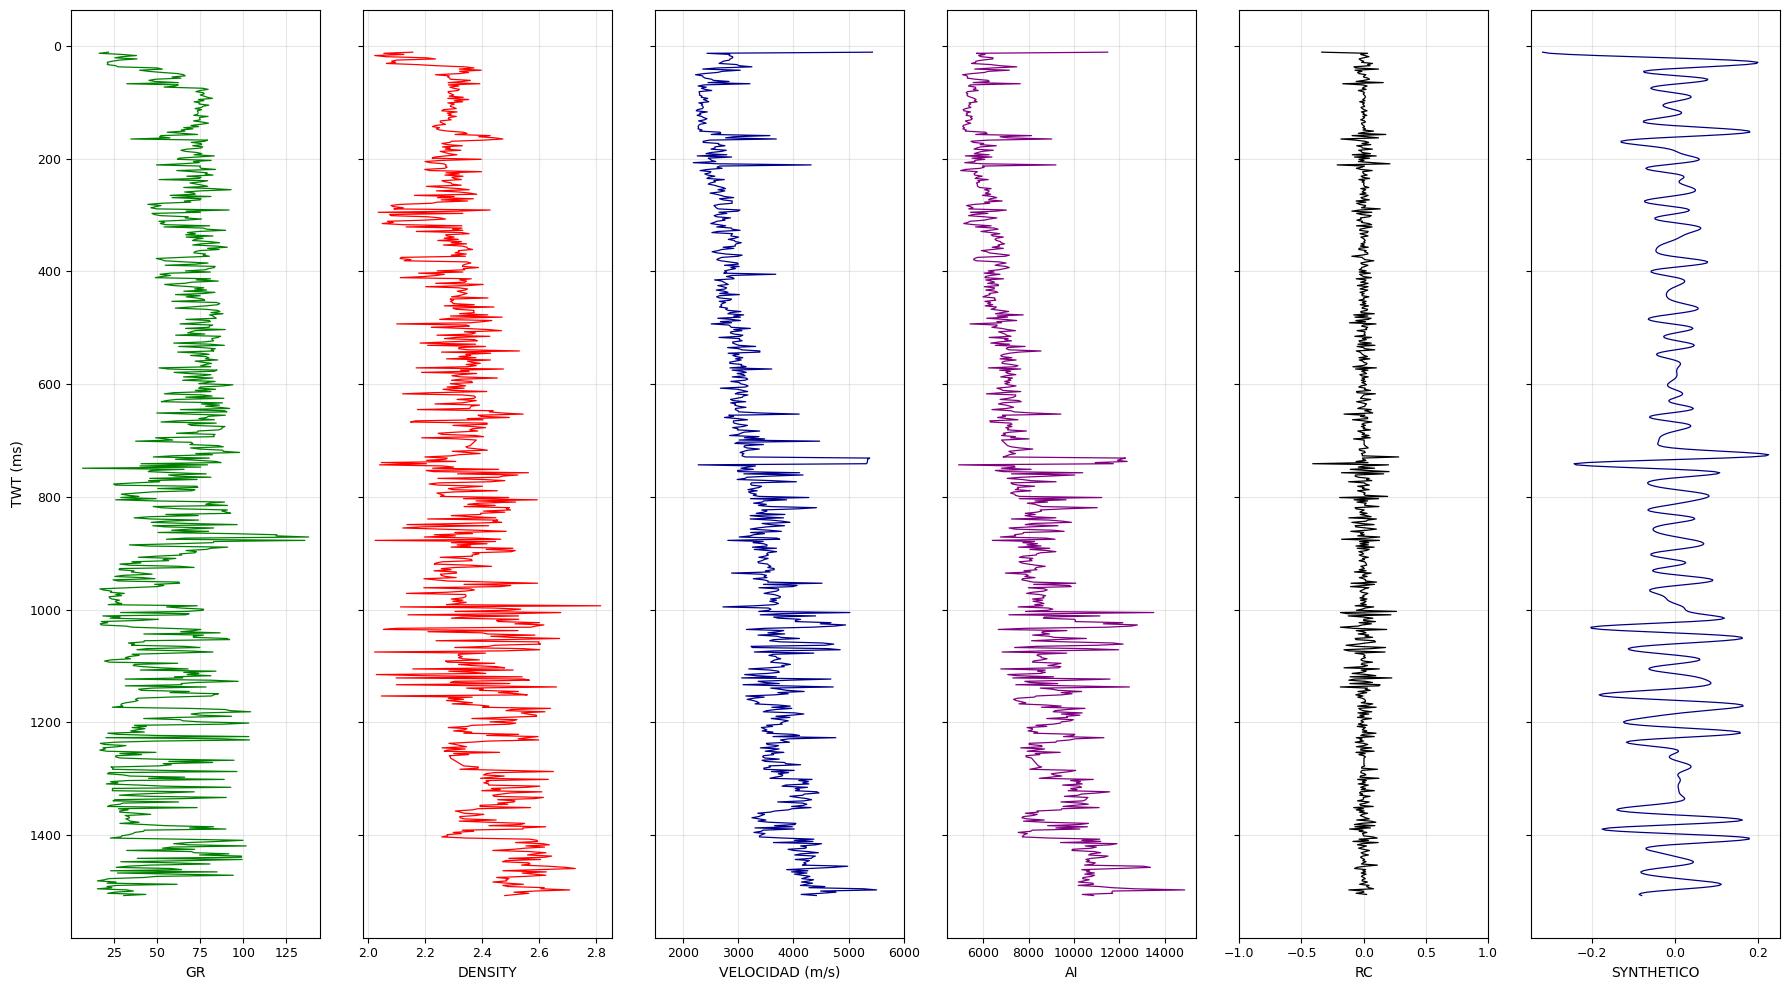

In [6]:
# 5) Plot final unico en TWT (seccion completa)
plot_final_twt_tracks(final_df)